In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import zipfile
with zipfile.ZipFile("/content/drive/MyDrive/Project/dataset.zip", 'r') as zip_ref:
  zip_ref.extractall("dataset")

In [6]:
import zipfile
import os
import shutil
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split

# Define paths
data_dir = 'dataset/dataset'


# Split dataset into train/val folders manually
def split_data(source_dir, train_dir, val_dir, split_ratio=0.8):
    if os.path.exists(train_dir):
        shutil.rmtree(train_dir)
    if os.path.exists(val_dir):
        shutil.rmtree(val_dir)
    os.makedirs(train_dir)
    os.makedirs(val_dir)

    for class_name in os.listdir(source_dir):
        class_path = os.path.join(source_dir, class_name)
        images = os.listdir(class_path)
        train_imgs, val_imgs = train_test_split(images, train_size=split_ratio, random_state=42, shuffle=True)

        os.makedirs(os.path.join(train_dir, class_name))
        os.makedirs(os.path.join(val_dir, class_name))

        for img in train_imgs:
            shutil.copy(os.path.join(class_path, img), os.path.join(train_dir, class_name, img))
        for img in val_imgs:
            shutil.copy(os.path.join(class_path, img), os.path.join(val_dir, class_name, img))

train_dir = '/kaggle/working/train'
val_dir = '/kaggle/working/val'

split_data(data_dir, train_dir, val_dir)

# Data generators
img_size = 224
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)


val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(train_dir,
                                              target_size=(img_size, img_size),
                                              batch_size=batch_size,
                                              class_mode='categorical')

val_gen = val_datagen.flow_from_directory(val_dir,
                                          target_size=(img_size, img_size),
                                          batch_size=batch_size,
                                          class_mode='categorical')

Found 5094 images belonging to 5 classes.
Found 1276 images belonging to 5 classes.


In [7]:
# Load base model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))
# 🔓 Unfreeze some layers (e.g., last 4 conv layers of VGG16)
base_model.trainable = True

# Freeze all layers except the last 4
for layer in base_model.layers[:-4]:
    layer.trainable = False


model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.5),  # 50% dropout
    Dense(128, activation='relu'),
    Dropout(0.3),  # Optional: another Dropout
    Dense(train_gen.num_classes, activation='softmax')
])


# Compile
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train
history = model.fit(train_gen,
                    epochs=10,
                    validation_data=val_gen)

# Save model
model.save('art_style_classifier.h5')

Epoch 1/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 154s 930ms/step - accuracy: 0.4912 - loss: 1.2518 - val_accuracy: 0.7641 - val_loss: 0.6373
Epoch 2/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 145s 908ms/step - accuracy: 0.7519 - loss: 0.6886 - val_accuracy: 0.7704 - val_loss: 0.6122
Epoch 3/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 147s 922ms/step - accuracy: 0.7907 - loss: 0.5769 - val_accuracy: 0.8135 - val_loss: 0.5094
Epoch 4/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 145s 909ms/step - accuracy: 0.8063 - loss: 0.4889 - val_accuracy: 0.8127 - val_loss: 0.4805
Epoch 5/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 146s 916ms/step - accuracy: 0.8249 - loss: 0.4730 - val_accuracy: 0.8323 - val_loss: 0.4723
Epoch 6/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 146s 914ms/step - accuracy: 0.8634 - loss: 0.3775 - val_accuracy: 0.8197 - val_loss: 0.5283
Epoch 7/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 145s 905ms/step - accuracy: 0.8730 - loss: 0.3359 - val_accuracy: 0.8386 - val_loss: 0.4747
Epoch 8/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 146s 915ms/step - accuracy: 0.8897 -

In [11]:
# Save model
model.save('art_style_classifier.h5')

# Class label (only works if your generator has class_indices)
class_indices = train_gen.class_indices
labels = {v: k for k, v in class_indices.items()}
print(labels.values())

dict_values(['Early_renaissance', 'Fauvism', 'Minimalism', 'Pop_art', 'rococo'])


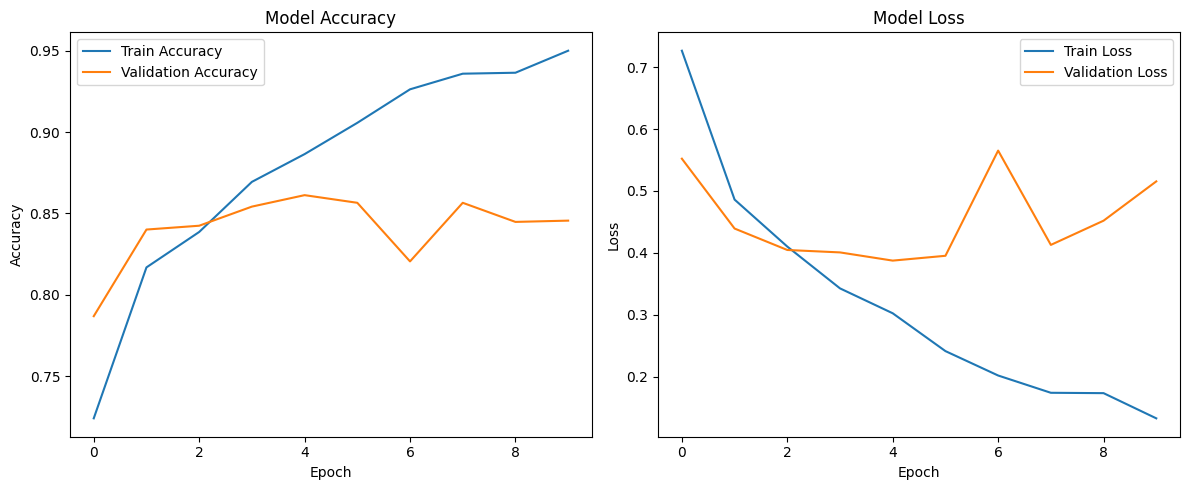

In [5]:
#VISUALIZATION

import matplotlib.pyplot as plt

# Assuming you saved your training history
history = model.history

# Accuracy plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()
